# CNN-Based Soil Image Classification

This notebook develops a CNN-based soil image classification model using
transfer learning.

## Objectives

- Load the cleaned and split soil-image dataset
- Verify the seven soil classes
- Visualize representative training images
- Use EfficientNetB0 with ImageNet pretrained weights
- Train a classification head while initially freezing the pretrained base
- Monitor training and validation performance
- Evaluate the initial model on the test set
- Fine-tune selected upper layers of EfficientNetB0
- Compare the fine-tuned model with the initial model
- Analyze classification performance using accuracy, precision, recall,
  F1-score, and a confusion matrix
- Inspect incorrect predictions
- Save the best-performing model for downstream explainability and
  hybrid analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
train_dir = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split/train"

val_dir = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split/validation"

test_dir = "/content/drive/MyDrive/Soil_Analytics_Project/Data/Processed/Image_Split/test"

In [ ]:
print("Training folder exists:", os.path.exists(train_dir))
print("Validation folder exists:", os.path.exists(val_dir))
print("Test folder exists:", os.path.exists(test_dir))

Training folder exists: True
Validation folder exists: True
Test folder exists: True


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42,
    label_mode="int"
)

Found 793 files belonging to 7 classes.
Found 168 files belonging to 7 classes.
Found 178 files belonging to 7 classes.


In [ ]:
class_names = train_ds.class_names

print("Soil Classes:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

Soil Classes:
['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']

Number of Classes: 7


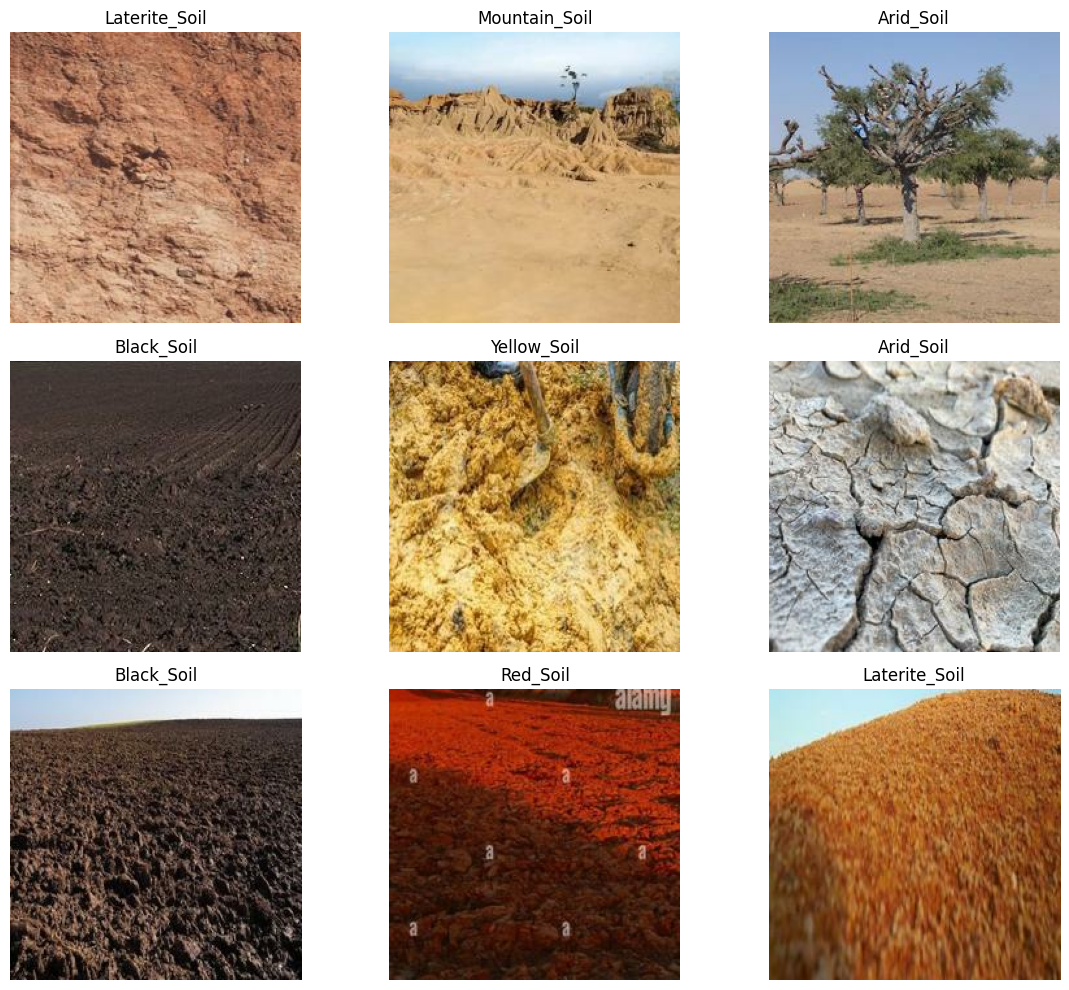

In [ ]:
plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class_names[2]

'Black_Soil'

## Model Selection — EfficientNetB0

EfficientNetB0 was selected as the CNN backbone for this project.

The image dataset contains a relatively small number of images, so a
computationally efficient architecture is appropriate. EfficientNet uses
compound scaling to balance network depth, width, and input resolution.

EfficientNetB0 also provides ImageNet-pretrained weights, allowing transfer
learning instead of training a deep CNN entirely from scratch.

ResNet-50 was considered as an alternative architecture. EfficientNetB0 was
selected for the current implementation because it provides a relatively
lightweight transfer-learning backbone while still offering strong feature
extraction capability.

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras import layers, models
num_classes = len(class_names)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
model_path = "/content/drive/MyDrive/Soil_Analytics_Project/Models/efficientnet_soil_classifier.keras"

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 185s 6s/step - accuracy: 0.3720 - loss: 1.6811 - val_accuracy: 0.6310 - val_loss: 1.1743
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6683 - loss: 1.0361 - val_accuracy: 0.7619 - val_loss: 0.8411
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.7793 - loss: 0.7663 - val_accuracy: 0.8155 - val_loss: 0.6897
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8298 - loss: 0.6204 - val_accuracy: 0.8452 - val_loss: 0.6121
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.8752 - loss: 0.5347 - val_accuracy: 0.8452 - val_loss: 0.5598
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.8689 - loss: 0.4653 - val_accuracy: 0.8631 - val_loss: 0.5274
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.8941 - loss: 0.4164 - val_accuracy: 0.8631 - val_loss: 0.5036
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9092 - loss: 0.3842 - val_accuracy: 0.8

In [ ]:
import os

model_path = "/content/drive/MyDrive/Soil_Analytics_Project/Models/efficientnet_soil_classifier.keras"

print("Model exists:", os.path.exists(model_path))

Model exists: True


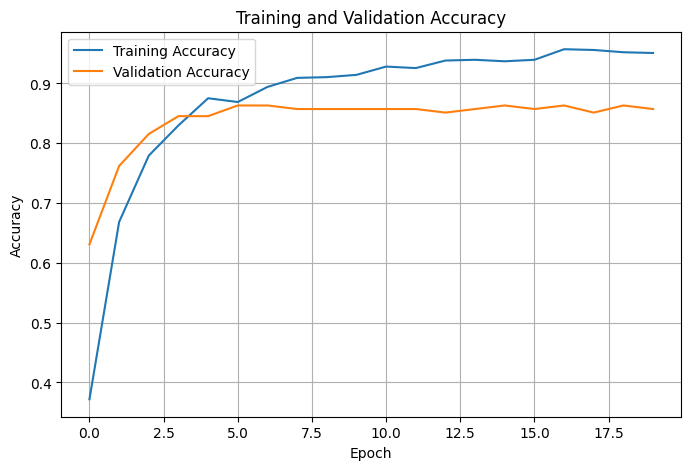

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

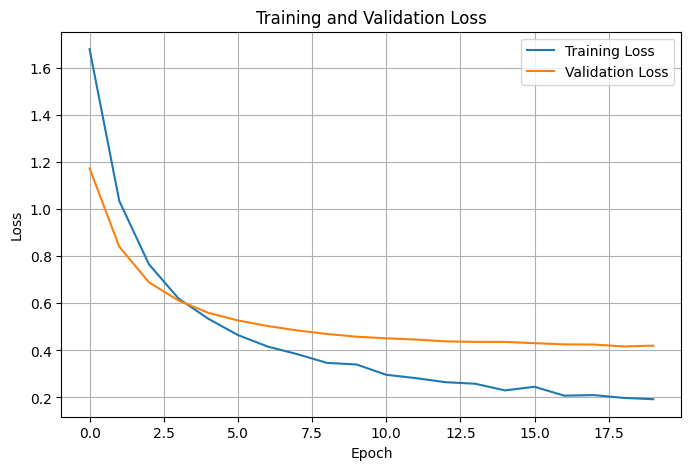

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Soil_Analytics_Project/Models/efficientnet_soil_classifier.keras"
)

In [ ]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.9045 - loss: 0.3248
Test Loss: 0.3248
Test Accuracy: 0.9045


In [ ]:
y_pred_prob = best_model.predict(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


In [ ]:
y_pred = np.argmax(y_pred_prob, axis=1)

In [ ]:
y_true = np.concatenate([
    labels.numpy() for images, labels in test_ds
])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

Alluvial_Soil       0.67      0.25      0.36         8
    Arid_Soil       0.91      0.93      0.92        43
   Black_Soil       0.95      0.97      0.96        36
Laterite_Soil       0.82      0.97      0.89        33
Mountain_Soil       0.90      0.93      0.92        30
     Red_Soil       1.00      0.88      0.94        17
  Yellow_Soil       1.00      0.82      0.90        11

     accuracy                           0.90       178
    macro avg       0.89      0.82      0.84       178
 weighted avg       0.90      0.90      0.90       178



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 2  2  0  3  1  0  0]
 [ 0 40  0  1  2  0  0]
 [ 0  1 35  0  0  0  0]
 [ 0  1  0 32  0  0  0]
 [ 1  0  1  0 28  0  0]
 [ 0  0  1  1  0 15  0]
 [ 0  0  0  2  0  0  9]]


<Figure size 1000x800 with 0 Axes>

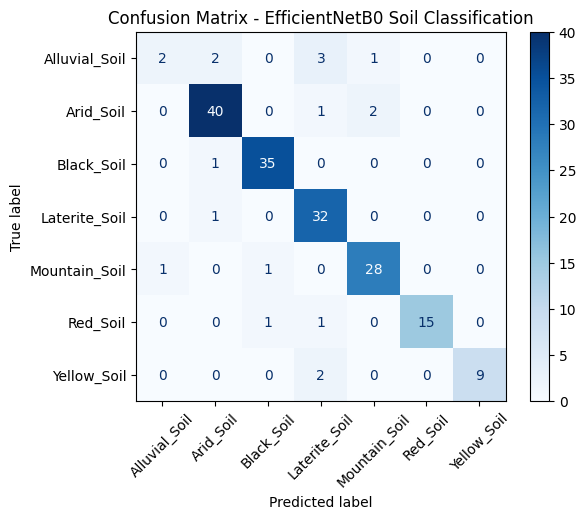

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - EfficientNetB0 Soil Classification")
plt.show()

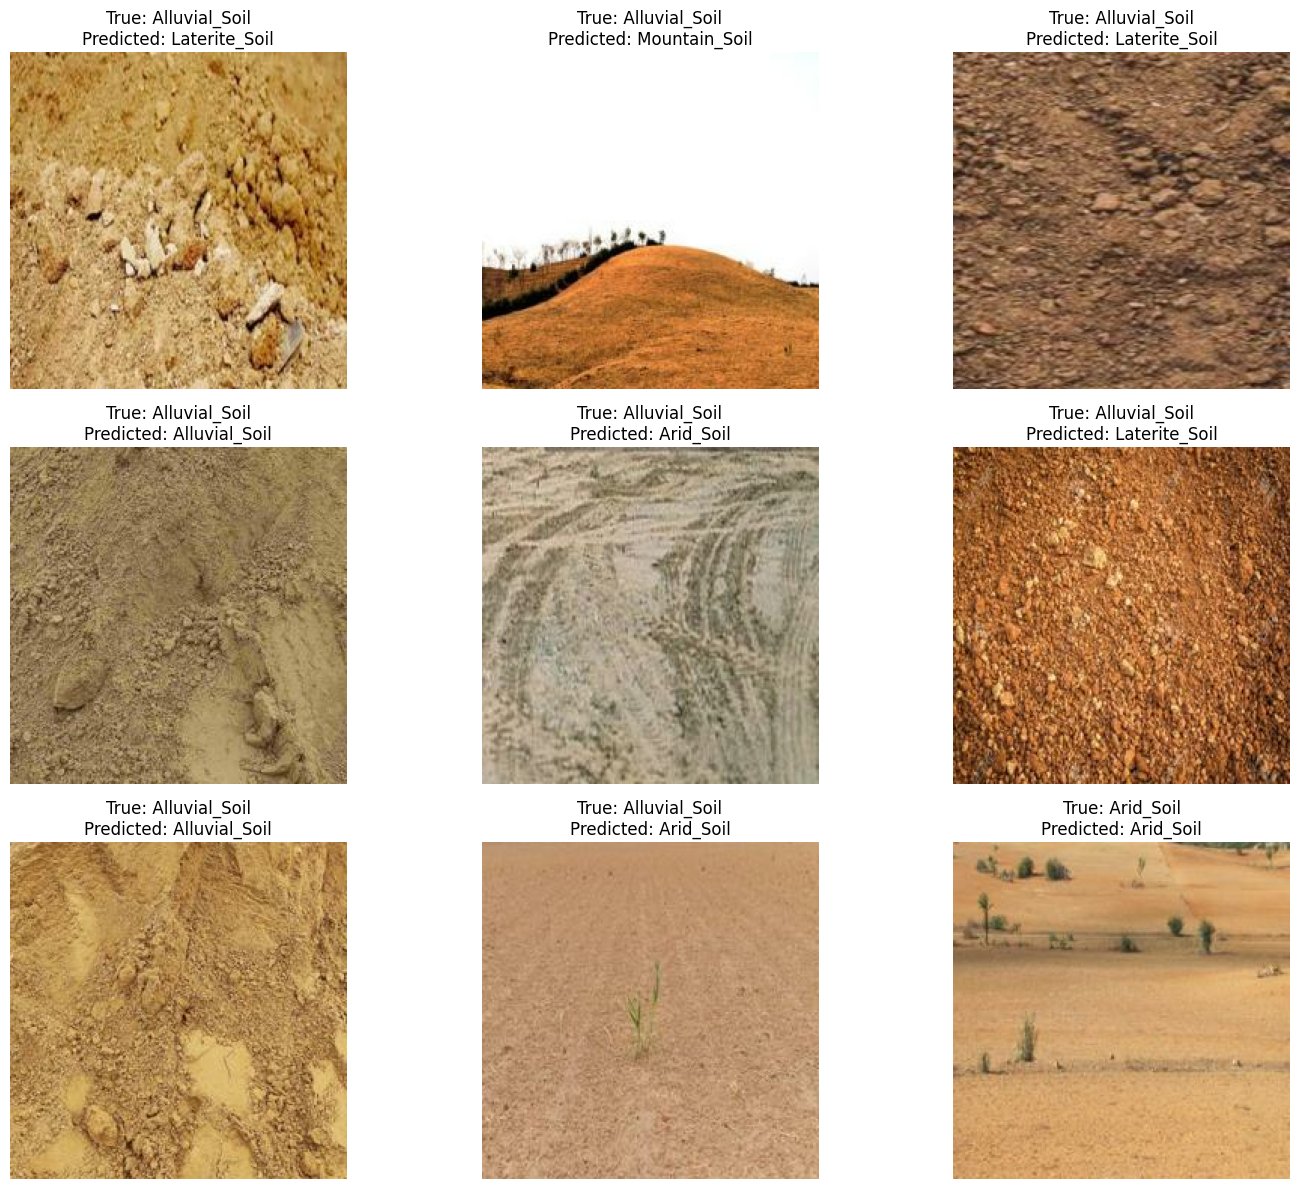

In [ ]:
plt.figure(figsize=(15, 12))

for images, labels in test_ds.take(1):

    predictions = best_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[predicted_labels[i]]

        plt.title(
            f"True: {true_label}\nPredicted: {predicted_label}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

## Initial Model Evaluation

The initial transfer-learning model achieved approximately **90.45% test
accuracy**.

The training and validation curves show that the model learns effectively,
but the increasing gap between training and validation performance indicates
some degree of overfitting.

Fine-tuning is therefore performed to allow selected higher-level
EfficientNet features to adapt more closely to the soil-image dataset.

In [ ]:
all_images = []
all_labels = []

for images, labels in test_ds:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.concatenate(all_images)
all_labels = np.concatenate(all_labels)

incorrect_indices = np.where(y_pred != all_labels)[0]

print("Total incorrect predictions:", len(incorrect_indices))

Total incorrect predictions: 17


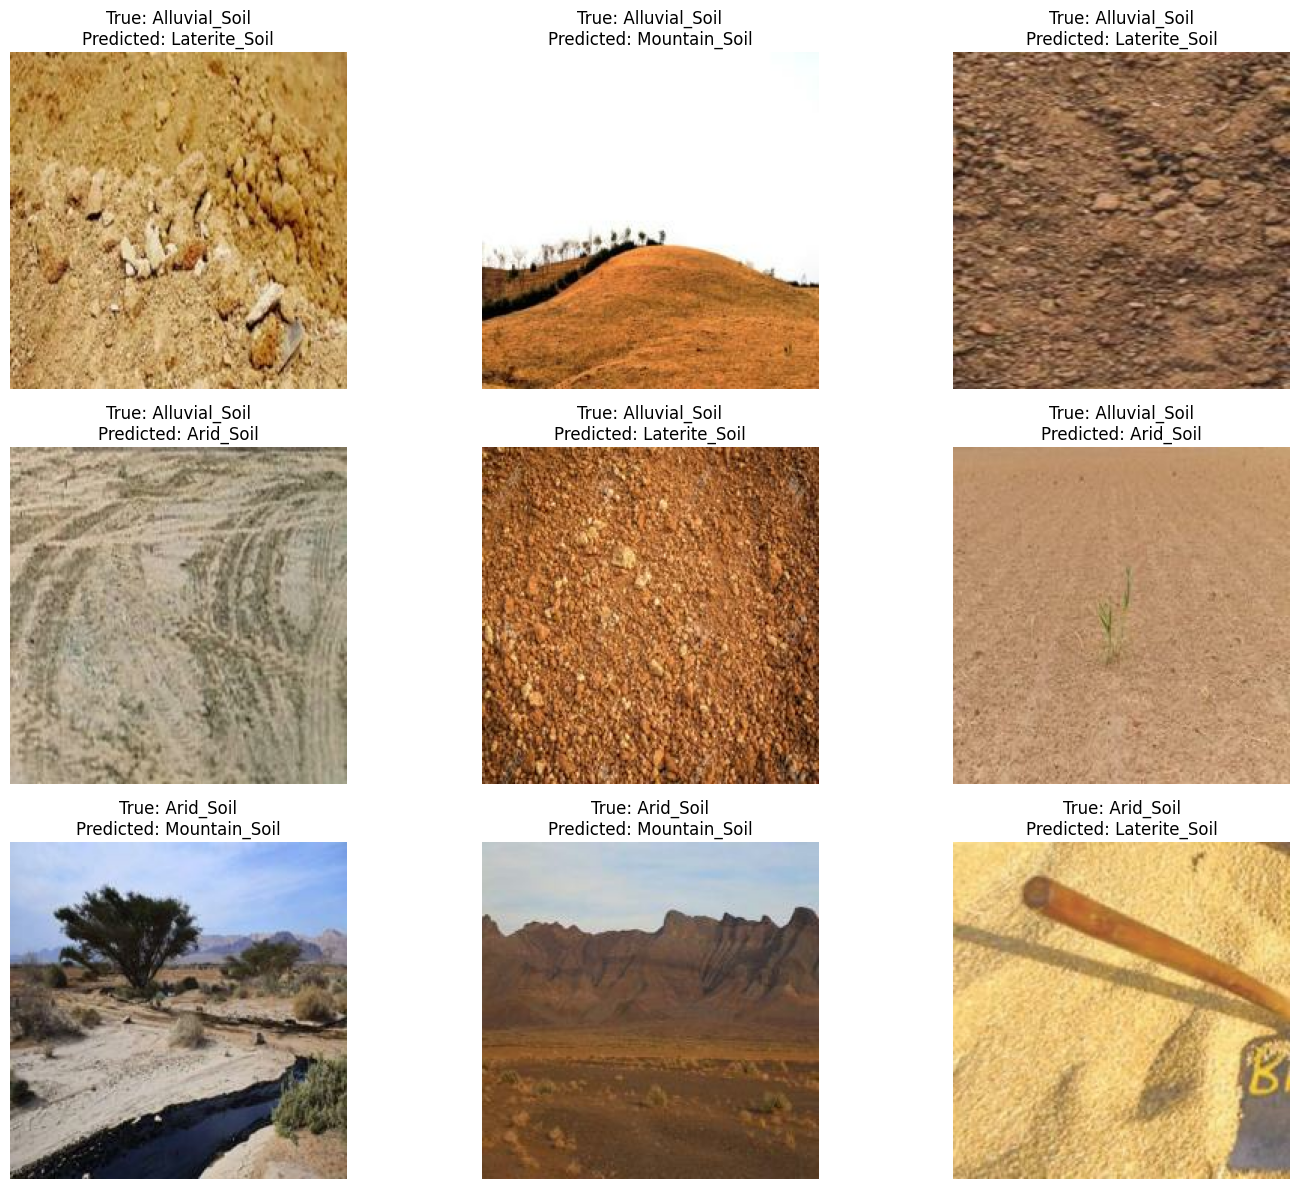

In [ ]:
plt.figure(figsize=(15, 12))

for i, idx in enumerate(incorrect_indices[:9]):

    plt.subplot(3, 3, i + 1)

    plt.imshow(all_images[idx].astype("uint8"))

    true_label = class_names[all_labels[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(
        f"True: {true_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
print("Total layers in base model:", len(base_model.layers))

trainable_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Trainable layers in base model:", trainable_layers)

Total layers in base model: 238
Trainable layers in base model: 38


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tuned_model_path = "/content/drive/MyDrive/Soil_Analytics_Project/Models/efficientnet_soil_classifier_finetuned.keras"

fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

fine_tune_checkpoint = ModelCheckpoint(
    fine_tuned_model_path,
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_checkpoint
    ]
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8398 - loss: 0.6101 - val_accuracy: 0.8571 - val_loss: 0.4318
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8398 - loss: 0.5618 - val_accuracy: 0.8690 - val_loss: 0.4580
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8701 - loss: 0.5173 - val_accuracy: 0.8631 - val_loss: 0.4855
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8739 - loss: 0.4848 - val_accuracy: 0.8631 - val_loss: 0.5105
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8752 - loss: 0.4670 - val_accuracy: 0.8393 - val_loss: 0.5297
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9004 - loss: 0.4190 - val_accuracy: 0.8333 - val_loss: 0.5452


In [ ]:
best_fine_tuned_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Soil_Analytics_Project/Models/efficientnet_soil_classifier_finetuned.keras"
)

In [ ]:
fine_tuned_test_loss, fine_tuned_test_accuracy = best_fine_tuned_model.evaluate(test_ds)

print(f"Fine-Tuned Test Loss: {fine_tuned_test_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {fine_tuned_test_accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 963ms/step - accuracy: 0.9213 - loss: 0.3339
Fine-Tuned Test Loss: 0.3339
Fine-Tuned Test Accuracy: 0.9213


In [ ]:

y_pred_prob_ft = best_fine_tuned_model.predict(test_ds)


y_pred_ft = np.argmax(y_pred_prob_ft, axis=1)

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_ft,
    target_names=class_names
))

               precision    recall  f1-score   support

Alluvial_Soil       0.67      0.25      0.36         8
    Arid_Soil       0.91      0.93      0.92        43
   Black_Soil       0.97      0.97      0.97        36
Laterite_Soil       0.88      0.91      0.90        33
Mountain_Soil       0.91      0.97      0.94        30
     Red_Soil       1.00      1.00      1.00        17
  Yellow_Soil       0.92      1.00      0.96        11

     accuracy                           0.92       178
    macro avg       0.89      0.86      0.86       178
 weighted avg       0.91      0.92      0.91       178



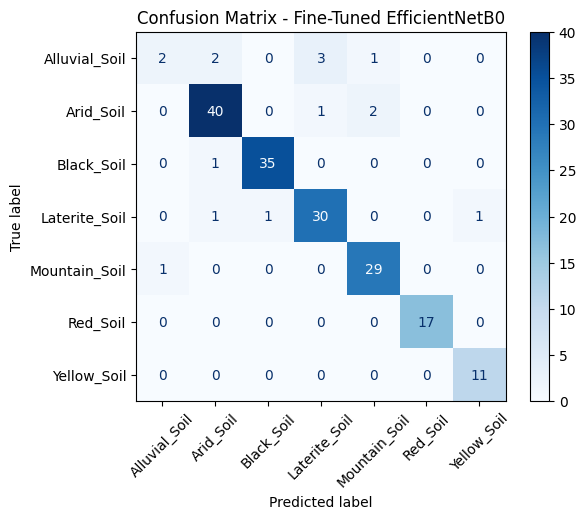

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_ft = confusion_matrix(y_true, y_pred_ft)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Fine-Tuned EfficientNetB0")
plt.show()

In [ ]:
## Fine-Tuning Results

The fine-tuned EfficientNetB0 achieved approximately **92.13% test accuracy**,
compared with **90.45%** for the initial transfer-learning model.

This represents an improvement of approximately **1.68 percentage points**.

The fine-tuned model was selected as the final image-classification model
because it provided the stronger test-set performance and is used by the
subsequent Grad-CAM and hybrid-analysis notebooks.

# CNN Classification — Final Summary

## Dataset

- 7 soil classes
- Training images: **793**
- Validation images: **168**
- Test images: **178**
- Input resolution: **224 × 224**
- Input channels: **RGB**

## Model

- Architecture: **EfficientNetB0**
- Pretrained weights: **ImageNet**
- Initial training: pretrained base frozen
- Fine-tuning: upper EfficientNet layers unfrozen
- Fine-tuning learning rate: **1e-5**
- Classification output: **7-class softmax**

## Results

| Model | Test Accuracy |
|---|---:|
| Initial EfficientNetB0 | **90.45%** |
| Fine-tuned EfficientNetB0 | **92.13%** |

The fine-tuned EfficientNetB0 is selected as the final CNN model.

The final model is saved as:

`efficientnet_soil_classifier_finetuned.keras`

and is subsequently used for Grad-CAM explainability and the hybrid soil
analysis pipeline.

## Interpretation

The final model provides strong overall classification performance, although
performance varies across soil classes. The confusion matrix and final
incorrect-prediction analysis are used to identify class-specific errors.

The model should be interpreted as a soil-image classification system rather
than as a laboratory soil-testing replacement.